# Seed 00 instantaneous controls across epsilon_ff

Jupytext-compatible diagnostic.

For seed 00 in each finite star-formation model

    epsilon_ff = 0.01, 0.03, 0.10, 0.30, 1.00

this script independently constructs an instantaneous control using the same
method as the previous finite-versus-instantaneous analysis:

  1. recover the primordial NAME=1--150 population from snapshot 0;
  2. append all later SINGLE/BINARY entries from gradual.97;
  3. remove any overlap with the primordial NAME range;
  4. assign every system an instantaneous birth time of zero;
  5. compare the resulting instantaneous populations without relying on
     cross-model NAME values or formation order;
  6. optionally interpolate them through the same SPISEA grid at common ages
     and compare the resulting HRD/CMD populations.

Main identity tests:

- unordered multiset of physical stellar component masses;
- unordered multiset of primary/system masses used by the current SPISEA
  instantaneous interpolation;
- synthetic observables at common ages.

Run:

    python compare_instantaneous_seed00_across_eff.py

Convert to notebook:

    jupytext --to notebook compare_instantaneous_seed00_across_eff.py

In [1]:
from __future__ import annotations

import contextlib
import io
import math
import os
import shutil
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Column, Table

from spisea import atmospheres, reddening, synthetic
from nbody62spisea import converter

sys.path.append('/home/wyz5rge/synthetic-cmd-dev/cmd_generator')
import interpolator  # noqa: E402

/home/wyz5rge/.venv/nbody/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /home/wyz5rge/SPISEA/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


particles.bound_subset and particles.bound_indexes will raise ImportError


## Configuration

In [2]:
ROOT = Path(
    '/standard/Tan_JC/backup_protoclusters/multiples/'
    'M3000new/sigma0p1/fiducial'
)

EFF_DIRS = {
    0.01: 'sfe_ff001',
    0.03: 'sfe_ff003',
    0.10: 'sfe_ff010',
    0.30: 'sfe_ff030',
    1.00: 'sfe_ff100',
}

SEED = '00'
REFERENCE_EFF = 0.03

UPDATED_MERGED_ROOT = Path(
    '/home/wyz5rge/SPISEA/evolution/merged/'
    'baraffe_pisa_ekstrom_parsec/'
)

OUTPUT_DIR = Path.cwd() / 'seed00_instantaneous_across_eff_outputs'
CACHE_DIR = Path.cwd() / 'analysis_cache' / 'instantaneous_seed00_across_eff'
ISO_CACHE_DIR = Path.cwd() / 'iso_cache'
MASTER_DIR = CACHE_DIR / 'master_catalogs'
INTERP_DIR = CACHE_DIR / 'interpolated'

for path in [OUTPUT_DIR, CACHE_DIR, MASTER_DIR, INTERP_DIR, ISO_CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RECOMPUTE_MASTERS = False
RECOMPUTE_INTERPOLATED = False
RESET_ISO_CACHE = False

SAVE_FIGURES = True
SHOW_FIGURES = True

N_PRIMORDIAL_COMPONENTS = 150

MASS_ATOL = 1.0e-10
MASS_RTOL = 1.0e-8
LOOSE_MASS_ATOL = 1.0e-6
LOOSE_MASS_RTOL = 1.0e-6

CHECK_TIMES_MYR = np.array([1.0, 2.0, 5.0, 10.0, 15.0, 20.0])

USE_ROTATING_MERGED = False
AKS = 0.0
DISTANCE_PC = 410.0
METALLICITY = 0.0
ATM_FUNC = atmospheres.get_BTSettl_2015_atmosphere
RED_LAW = reddening.RedLawHosek18b()

ISO_AGES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)
ISO_LOG_AGES = np.log10(ISO_AGES_MYR * 1.0e6)
L_SUN_WATTS = 3.846e26

FILTER_OBSMODES = {
    'F070W': 'jwst,F070W',
    'F140M': 'jwst,F140M',
    'F162M': 'jwst,F162M',
    'F182M': 'jwst,F182M',
    'F200W': 'jwst,F200W',
    'F555W': 'wfc3,uvis1,f555w',
    'F814W': 'wfc3,uvis1,f814w',
}
ALL_FILTERS = list(FILTER_OBSMODES.values())

In [3]:
def show_table(df: pd.DataFrame, n: int | None = None) -> None:
    if n is not None:
        df = df.head(n)
    try:
        from IPython.display import display
        display(df)
    except Exception:
        print(df.to_string(index=False))


def finish_figure(fig, filename: str) -> None:
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / filename, dpi=220, bbox_inches='tight')
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def simulation_path(eff: float) -> Path:
    path = ROOT / EFF_DIRS[eff] / SEED
    if not path.is_dir():
        raise FileNotFoundError(path)
    return path

## Merged evolutionary-model reader

In [4]:
class MergedBaraffePisaEkstromParsecDAT:
    def __init__(self, root_dir: Path | str, rot: bool = False):
        self.root_dir = Path(root_dir).expanduser().resolve()
        self.rot = bool(rot)
        self.model_dir = str(self.root_dir)
        self.z_list = [0.015]
        self.z_solar = 0.015
        self.mass_list = []
        self.grid_dir = self.root_dir / ('z015_rot' if rot else 'z015_norot')
        if not self.grid_dir.is_dir():
            raise FileNotFoundError(self.grid_dir)

        self.age_file_map = {}
        for path in sorted(self.grid_dir.glob('iso_*.dat')):
            try:
                log_age = float(path.stem.split('_')[1])
            except (IndexError, ValueError):
                continue
            self.age_file_map[round(log_age, 2)] = path

        if not self.age_file_map:
            raise FileNotFoundError(f'No iso_*.dat files in {self.grid_dir}')

        self.age_list = np.array(sorted(self.age_file_map), dtype=float)

    def isochrone(self, age: float = 1.0e6, metallicity: float = 0.0) -> Table:
        requested = math.log10(age)
        if requested < self.age_list[0] or requested > self.age_list[-1]:
            raise ValueError(f'logAge {requested:.4f} outside merged grid')

        idx = int(np.argmin(np.abs(self.age_list - requested)))
        selected = float(self.age_list[idx])
        path = self.age_file_map[round(selected, 2)]

        dtype = [
            ('mass', 'f8'),
            ('logT', 'f8'),
            ('logL', 'f8'),
            ('logg', 'f8'),
            ('logT_WR', 'f8'),
            ('mass_current', 'f8'),
            ('phase', 'i4'),
            ('model_ref', 'U32'),
        ]

        data = np.genfromtxt(path, comments='#', dtype=dtype, encoding='utf-8')
        iso = Table(np.atleast_1d(data))
        iso.add_column(
            Column(
                ~np.isclose(
                    np.asarray(iso['logT'], float),
                    np.asarray(iso['logT_WR'], float),
                    rtol=0.0,
                    atol=1.0e-8,
                ),
                name='isWR',
            )
        )
        iso.meta.update({
            'log_age': selected,
            'log_age_requested': requested,
            'metallicity_in': metallicity,
            'metallicity_act': 0.0,
            'source_file': str(path),
        })
        return iso

In [5]:
@dataclass
class IsoGrid:
    ages_myr: np.ndarray
    log_ages: np.ndarray
    isochrones: list
    coverage: pd.DataFrame
    filter_columns: dict[str, str]


def normalize_name(value):
    return ''.join(ch.lower() for ch in str(value) if ch.isalnum())


def resolve_filter_column(colnames, filter_name):
    target = normalize_name(filter_name)
    candidates = [
        c for c in colnames
        if normalize_name(c).startswith('m')
        and normalize_name(c).endswith(target)
    ]
    instrument = 'hst' if filter_name in {'F555W', 'F814W'} else 'jwst'
    preferred = [c for c in candidates if instrument in normalize_name(c)]

    if len(preferred) == 1:
        return preferred[0]
    if len(candidates) == 1:
        return candidates[0]

    raise KeyError(
        f'Cannot resolve {filter_name}; candidates={candidates}; '
        f'available={list(colnames)}'
    )


def safe_interpolate(age_myr, mass, grid, log_ages, filters):
    try:
        with warnings.catch_warnings(),                 contextlib.redirect_stdout(io.StringIO()),                 contextlib.redirect_stderr(io.StringIO()):
            warnings.simplefilter('ignore')
            result = interpolator.interpolate(
                age_myr, mass, grid, log_ages, list(filters)
            )

        if result is None:
            return None

        result = np.asarray(result, float)
        if result.size != 3 + len(filters) or not np.all(np.isfinite(result)):
            return None

        return result

    except Exception:
        return None


def build_iso_grid(evo_model):
    if RESET_ISO_CACHE and ISO_CACHE_DIR.exists():
        shutil.rmtree(ISO_CACHE_DIR)
        ISO_CACHE_DIR.mkdir(parents=True, exist_ok=True)

    isochrones = []
    records = []
    filter_columns = None

    for age_myr, log_age in zip(ISO_AGES_MYR, ISO_LOG_AGES):
        print(f'Building/loading {age_myr:4.1f} Myr isochrone')
        try:
            iso = synthetic.IsochronePhot(
                log_age,
                AKS,
                DISTANCE_PC,
                metallicity=METALLICITY,
                evo_model=evo_model,
                atm_func=ATM_FUNC,
                red_law=RED_LAW,
                filters=ALL_FILTERS,
                iso_dir=str(ISO_CACHE_DIR),
            )

            current = {
                name: resolve_filter_column(iso.points.colnames, name)
                for name in FILTER_OBSMODES
            }

            if filter_columns is None:
                filter_columns = current
            elif current != filter_columns:
                raise RuntimeError('Magnitude columns changed across ages')

            mass = np.asarray(iso.points['mass'], float)

            isochrones.append(iso)
            records.append({
                'age_myr': age_myr,
                'status': 'success',
                'n_points': len(iso.points),
                'mass_min': np.nanmin(mass),
                'mass_max': np.nanmax(mass),
                'error': '',
            })

        except Exception as exc:
            isochrones.append(None)
            records.append({
                'age_myr': age_myr,
                'status': 'failed',
                'n_points': 0,
                'mass_min': np.nan,
                'mass_max': np.nan,
                'error': str(exc),
            })
            print(f'  FAILED: {exc}')

    if filter_columns is None:
        raise RuntimeError('No isochrones were built')

    return IsoGrid(
        ISO_AGES_MYR.copy(),
        ISO_LOG_AGES.copy(),
        isochrones,
        pd.DataFrame(records),
        filter_columns,
    )

## Instantaneous master construction

In [6]:
def parse_gradual_formation_file(simulation_path: Path | str):
    gradual_path = Path(simulation_path) / 'gradual.97'
    if not gradual_path.is_file():
        raise FileNotFoundError(gradual_path)

    singles = []
    binaries = []

    with gradual_path.open() as handle:
        for line_number, line in enumerate(handle, start=1):
            fields = line.strip().split()

            if not fields or len(fields) < 2 or fields[1] == 'TIME':
                continue

            record_type = fields[0].upper()

            if record_type == 'SINGLE':
                singles.append({
                    'system_name': int(fields[3]),
                    'primary_name': int(fields[3]),
                    'companion_name': -1,
                    'is_multiple': False,
                    'primary_initial_mass': float(fields[4]),
                    'companion_initial_mass': np.nan,
                    'system_initial_mass': float(fields[4]),
                    'original_birth_time_myr': float(fields[2]),
                    'source': 'gradual.97',
                    'source_line': line_number,
                })

            elif record_type == 'BINARY':
                m1 = float(fields[5])
                m2 = float(fields[6])

                binaries.append({
                    'system_name': int(fields[3]),
                    'primary_name': int(fields[3]),
                    'companion_name': int(fields[4]),
                    'is_multiple': True,
                    'primary_initial_mass': m1,
                    'companion_initial_mass': m2,
                    'system_initial_mass': m1 + m2,
                    'original_birth_time_myr': float(fields[2]),
                    'source': 'gradual.97',
                    'source_line': line_number,
                })

    return singles, binaries


def primordial_snapshot_zero_systems(simulation_path: Path | str) -> pd.DataFrame:
    data = converter.get_binary_data(os.path.abspath(str(simulation_path)), 0)

    candidate_single_names = np.asarray(data['single'], dtype=int)
    candidate_single_masses = np.asarray(data['msingle'], dtype=float)

    primary_names = np.asarray(data['primary'], dtype=int)
    secondary_names = np.asarray(data['secondary'], dtype=int)
    primary_masses = np.asarray(data['m1'], dtype=float)
    secondary_masses = np.asarray(data['m2'], dtype=float)

    primordial_binary_mask = (
        (primary_names >= 1)
        & (primary_names <= N_PRIMORDIAL_COMPONENTS)
        & (secondary_names >= 1)
        & (secondary_names <= N_PRIMORDIAL_COMPONENTS)
    )

    pnames = primary_names[primordial_binary_mask]
    snames = secondary_names[primordial_binary_mask]
    pmass = primary_masses[primordial_binary_mask]
    smass = secondary_masses[primordial_binary_mask]

    binary_components = np.concatenate([pnames, snames])

    single_mask = (
        (candidate_single_names >= 1)
        & (candidate_single_names <= N_PRIMORDIAL_COMPONENTS)
        & ~np.isin(candidate_single_names, binary_components)
    )

    singles = pd.DataFrame({
        'system_name': candidate_single_names[single_mask],
        'primary_name': candidate_single_names[single_mask],
        'companion_name': -1,
        'is_multiple': False,
        'primary_initial_mass': candidate_single_masses[single_mask],
        'companion_initial_mass': np.nan,
        'system_initial_mass': candidate_single_masses[single_mask],
        'original_birth_time_myr': 0.0,
        'source': 'snapshot_0_primordial_single',
        'source_line': -1,
    })

    binaries = pd.DataFrame({
        'system_name': pnames,
        'primary_name': pnames,
        'companion_name': snames,
        'is_multiple': True,
        'primary_initial_mass': pmass,
        'companion_initial_mass': smass,
        'system_initial_mass': pmass + smass,
        'original_birth_time_myr': 0.0,
        'source': 'snapshot_0_primordial_binary',
        'source_line': -1,
    })

    primordial = pd.concat([singles, binaries], ignore_index=True)

    component_names = np.concatenate([
        primordial['primary_name'].to_numpy(int),
        primordial.loc[
            primordial['is_multiple'].astype(bool),
            'companion_name',
        ].to_numpy(int),
    ])

    expected = set(range(1, N_PRIMORDIAL_COMPONENTS + 1))
    recovered = set(component_names.tolist())

    if recovered != expected:
        raise RuntimeError(
            f'Primordial NAME recovery failed. '
            f'Missing={sorted(expected - recovered)}, '
            f'Unexpected={sorted(recovered - expected)}'
        )

    return primordial


def validate_master_catalog(master: pd.DataFrame) -> None:
    primary_names = master['primary_name'].to_numpy(int)
    binary_mask = master['is_multiple'].astype(bool)
    companion_names = master.loc[binary_mask, 'companion_name'].to_numpy(int)

    component_names = np.concatenate([primary_names, companion_names])

    if pd.Series(component_names).duplicated().any():
        raise RuntimeError('Duplicate component NAME values remain')

    if not np.all(np.isfinite(master['primary_initial_mass'])):
        raise RuntimeError('Non-finite primary masses')

    if not np.all(np.isfinite(master.loc[binary_mask, 'companion_initial_mass'])):
        raise RuntimeError('Non-finite companion masses')


def build_instantaneous_master_catalog(simulation_path: Path | str) -> pd.DataFrame:
    primordial = primordial_snapshot_zero_systems(simulation_path)

    gradual_singles, gradual_binaries = parse_gradual_formation_file(
        simulation_path
    )
    gradual = pd.DataFrame(gradual_singles + gradual_binaries)

    overlap = (
        gradual['primary_name'].between(1, N_PRIMORDIAL_COMPONENTS)
        | (
            gradual['is_multiple'].astype(bool)
            & gradual['companion_name'].between(1, N_PRIMORDIAL_COMPONENTS)
        )
    )

    gradual = gradual.loc[~overlap].copy()

    master = pd.concat([primordial, gradual], ignore_index=True)
    master['instantaneous_birth_time_myr'] = 0.0

    validate_master_catalog(master)
    return master.reset_index(drop=True)


def master_cache_path(eff: float) -> Path:
    return MASTER_DIR / (
        f'{EFF_DIRS[eff]}_seed{SEED}_instantaneous_master.csv'
    )


masters = {}

for eff in EFF_DIRS:
    cache_path = master_cache_path(eff)

    if cache_path.exists() and not RECOMPUTE_MASTERS:
        master = pd.read_csv(cache_path)

        if master['is_multiple'].dtype == object:
            master['is_multiple'] = (
                master['is_multiple']
                .astype(str)
                .str.lower()
                .map({'true': True, 'false': False})
            )

        validate_master_catalog(master)

    else:
        master = build_instantaneous_master_catalog(simulation_path(eff))
        master.to_csv(cache_path, index=False)

    masters[eff] = master

    binary_mask = master['is_multiple'].astype(bool)

    print('=' * 72)
    print(f'epsilon_ff={eff:.2f}')
    print(f'  systems:    {len(master)}')
    print(f'  binaries:   {binary_mask.sum()}')
    print(f'  components: {len(master) + binary_mask.sum()}')
    print(f'  total mass: {master["system_initial_mass"].sum():.8f} Msun')

epsilon_ff=0.01
  systems:    2860
  binaries:   1430
  components: 4290
  total mass: 1501.49999998 Msun
epsilon_ff=0.03
  systems:    2822
  binaries:   1411
  components: 4233
  total mass: 1498.48200085 Msun


epsilon_ff=0.10
  systems:    2531
  binaries:   1265
  components: 3796
  total mass: 1499.42000036 Msun
epsilon_ff=0.30
  systems:    2472
  binaries:   1236
  components: 3708
  total mass: 1501.74000017 Msun
epsilon_ff=1.00
  systems:    2348
  binaries:   1174
  components: 3522
  total mass: 1500.37199945 Msun


## Compare instantaneous masters without using NAME/order

In [7]:
def component_mass_array(master: pd.DataFrame) -> np.ndarray:
    binary_mask = master['is_multiple'].astype(bool)
    return np.concatenate([
        master['primary_initial_mass'].to_numpy(float),
        master.loc[binary_mask, 'companion_initial_mass'].to_numpy(float),
    ])


def sorted_component_masses(master: pd.DataFrame) -> np.ndarray:
    return np.sort(component_mass_array(master))


def sorted_primary_masses(master: pd.DataFrame) -> np.ndarray:
    return np.sort(master['primary_initial_mass'].to_numpy(float))


def multiset_match(a, b, atol=MASS_ATOL, rtol=MASS_RTOL):
    a = np.sort(np.asarray(a, float))
    b = np.sort(np.asarray(b, float))

    if len(a) != len(b):
        return False, np.nan, np.nan

    diff = np.abs(a - b)

    return (
        bool(np.allclose(a, b, atol=atol, rtol=rtol)),
        float(np.max(diff)),
        float(np.median(diff)),
    )


inventory_rows = []

for eff, master in masters.items():
    binary_mask = master['is_multiple'].astype(bool)
    components = component_mass_array(master)

    inventory_rows.append({
        'epsilon_ff': eff,
        'n_systems': len(master),
        'n_single_systems': int((~binary_mask).sum()),
        'n_binary_systems': int(binary_mask.sum()),
        'n_components': len(components),
        'total_component_initial_mass_msun': float(components.sum()),
        'mean_component_mass_msun': float(components.mean()),
        'median_component_mass_msun': float(np.median(components)),
        'max_component_mass_msun': float(components.max()),
    })

df_inventory = pd.DataFrame(inventory_rows)
print('\nINSTANTANEOUS MASTER INVENTORY')
show_table(df_inventory)
df_inventory.to_csv(
    OUTPUT_DIR / 'instantaneous_master_inventory.csv',
    index=False,
)


ref_components = sorted_component_masses(masters[REFERENCE_EFF])
ref_primaries = sorted_primary_masses(masters[REFERENCE_EFF])

mass_rows = []

for eff, master in masters.items():
    components = sorted_component_masses(master)
    primaries = sorted_primary_masses(master)

    comp_exact, comp_max, comp_med = multiset_match(
        ref_components, components
    )
    comp_loose, _, _ = multiset_match(
        ref_components,
        components,
        atol=LOOSE_MASS_ATOL,
        rtol=LOOSE_MASS_RTOL,
    )

    prim_exact, prim_max, prim_med = multiset_match(
        ref_primaries, primaries
    )
    prim_loose, _, _ = multiset_match(
        ref_primaries,
        primaries,
        atol=LOOSE_MASS_ATOL,
        rtol=LOOSE_MASS_RTOL,
    )

    mass_rows.append({
        'epsilon_ff': eff,
        'reference_epsilon_ff': REFERENCE_EFF,
        'same_component_count': len(components) == len(ref_components),
        'same_total_component_mass': bool(
            np.isclose(
                components.sum(),
                ref_components.sum(),
                atol=MASS_ATOL,
                rtol=MASS_RTOL,
            )
        ),
        'exact_same_unordered_component_mass_multiset': comp_exact,
        'loose_same_unordered_component_mass_multiset': comp_loose,
        'component_mass_max_abs_sorted_difference': comp_max,
        'component_mass_median_abs_sorted_difference': comp_med,
        'same_system_count': len(primaries) == len(ref_primaries),
        'exact_same_unordered_primary_mass_multiset': prim_exact,
        'loose_same_unordered_primary_mass_multiset': prim_loose,
        'primary_mass_max_abs_sorted_difference': prim_max,
        'primary_mass_median_abs_sorted_difference': prim_med,
    })

df_mass_comparison = pd.DataFrame(mass_rows)
print('\nUNORDERED MASS-POPULATION COMPARISON')
show_table(df_mass_comparison)
df_mass_comparison.to_csv(
    OUTPUT_DIR / 'instantaneous_mass_population_comparison.csv',
    index=False,
)


INSTANTANEOUS MASTER INVENTORY


,epsilon_ff,n_systems,n_single_systems,n_binary_systems,n_components,total_component_initial_mass_msun,mean_component_mass_msun,median_component_mass_msun,max_component_mass_msun
0,0.01,2860,1430,1430,4290,1501.500000,0.350,0.119851,32.172083
1,0.03,2822,1411,1411,4233,1498.482001,0.354,0.118446,25.388293
2,0.10,2531,1266,1265,3796,1499.420000,0.395,0.119321,70.965048
3,0.30,2472,1236,1236,3708,1501.740000,0.405,0.118979,94.857453
4,1.00,2348,1174,1174,3522,1500.371999,0.426,0.116409,85.641140



UNORDERED MASS-POPULATION COMPARISON


,epsilon_ff,reference_epsilon_ff,same_component_count,same_total_component_mass,exact_same_unordered_component_mass_multiset,loose_same_unordered_component_mass_multiset,component_mass_max_abs_sorted_difference,component_mass_median_abs_sorted_difference,same_system_count,exact_same_unordered_primary_mass_multiset,loose_same_unordered_primary_mass_multiset,primary_mass_max_abs_sorted_difference,primary_mass_median_abs_sorted_difference
0,0.01,0.03,False,False,False,False,NaN,NaN,False,False,False,NaN,NaN
1,0.03,0.03,True,True,True,True,0.0,0.0,True,True,True,0.0,0.0
2,0.10,0.03,False,False,False,False,NaN,NaN,False,False,False,NaN,NaN
3,0.30,0.03,False,False,False,False,NaN,NaN,False,False,False,NaN,NaN
4,1.00,0.03,False,False,False,False,NaN,NaN,False,False,False,NaN,NaN


## Pairwise comparison across all epsilon_ff values

In [8]:
pairwise_rows = []
eff_values = list(EFF_DIRS)

for i, eff_a in enumerate(eff_values):
    for eff_b in eff_values[i + 1:]:
        a = sorted_component_masses(masters[eff_a])
        b = sorted_component_masses(masters[eff_b])

        exact, max_diff, med_diff = multiset_match(a, b)
        loose, _, _ = multiset_match(
            a,
            b,
            atol=LOOSE_MASS_ATOL,
            rtol=LOOSE_MASS_RTOL,
        )

        pairwise_rows.append({
            'epsilon_ff_a': eff_a,
            'epsilon_ff_b': eff_b,
            'n_components_a': len(a),
            'n_components_b': len(b),
            'same_component_count': len(a) == len(b),
            'exact_same_component_mass_multiset': exact,
            'loose_same_component_mass_multiset': loose,
            'max_abs_sorted_mass_difference': max_diff,
            'median_abs_sorted_mass_difference': med_diff,
        })

df_pairwise = pd.DataFrame(pairwise_rows)
print('\nPAIRWISE MASS COMPARISON')
show_table(df_pairwise)
df_pairwise.to_csv(
    OUTPUT_DIR / 'pairwise_instantaneous_mass_comparison.csv',
    index=False,
)


PAIRWISE MASS COMPARISON


,epsilon_ff_a,epsilon_ff_b,n_components_a,n_components_b,same_component_count,exact_same_component_mass_multiset,loose_same_component_mass_multiset,max_abs_sorted_mass_difference,median_abs_sorted_mass_difference
0,0.01,0.03,4290,4233,False,False,False,NaN,NaN
1,0.01,0.10,4290,3796,False,False,False,NaN,NaN
2,0.01,0.30,4290,3708,False,False,False,NaN,NaN
3,0.01,1.00,4290,3522,False,False,False,NaN,NaN
4,0.03,0.10,4233,3796,False,False,False,NaN,NaN
5,0.03,0.30,4233,3708,False,False,False,NaN,NaN
6,0.03,1.00,4233,3522,False,False,False,NaN,NaN
7,0.10,0.30,3796,3708,False,False,False,NaN,NaN
8,0.10,1.00,3796,3522,False,False,False,NaN,NaN
9,0.30,1.00,3708,3522,False,False,False,NaN,NaN


## Initial-mass distribution plots

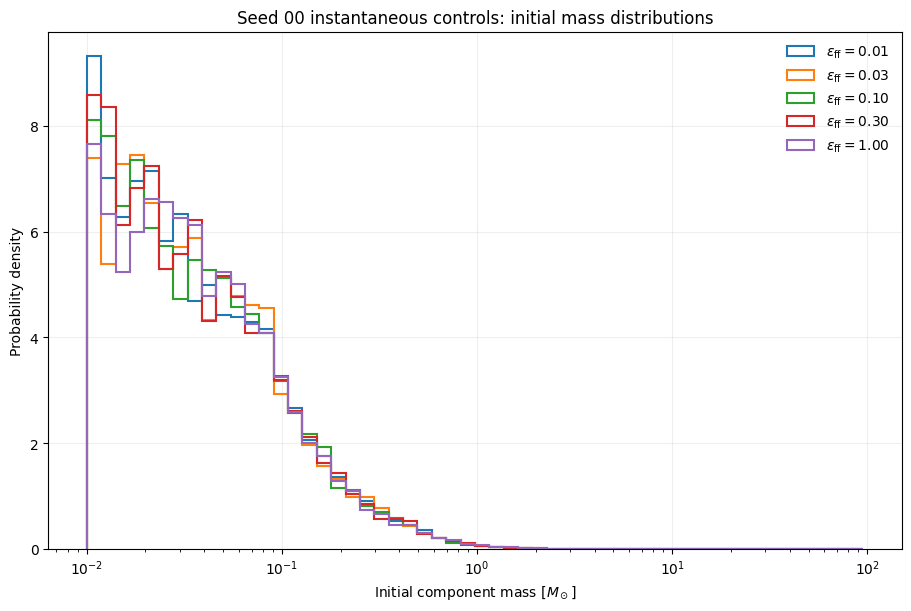

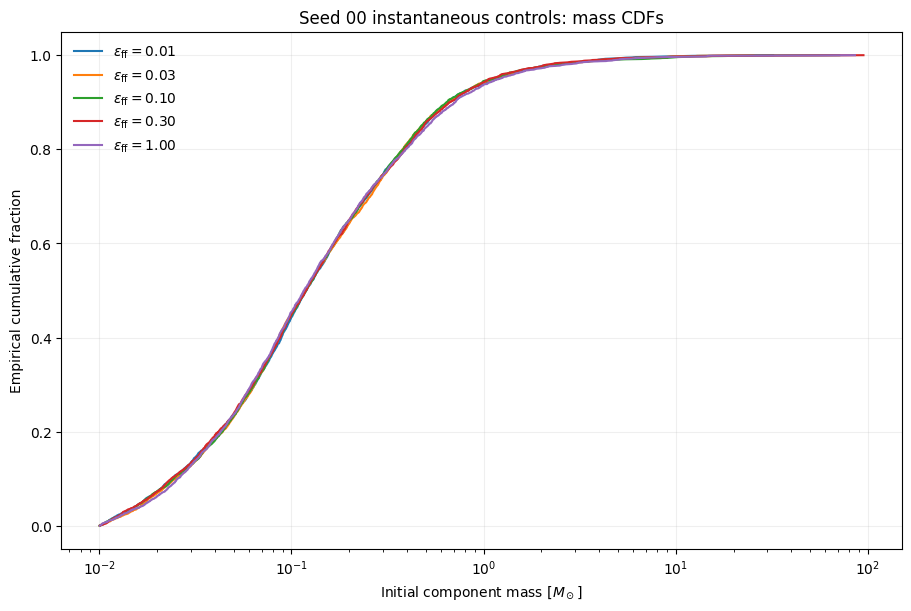

In [9]:
all_masses = np.concatenate([
    component_mass_array(master)
    for master in masters.values()
])

edges = np.logspace(
    np.log10(all_masses.min()),
    np.log10(all_masses.max()),
    55,
)

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)

for eff, master in masters.items():
    ax.hist(
        component_mass_array(master),
        bins=edges,
        histtype='step',
        density=True,
        linewidth=1.5,
        label=rf'$\epsilon_{{\rm ff}}={eff:.2f}$',
    )

ax.set_xscale('log')
ax.set_xlabel(r'Initial component mass [$M_\odot$]')
ax.set_ylabel('Probability density')
ax.set_title('Seed 00 instantaneous controls: initial mass distributions')
ax.grid(alpha=0.2)
ax.legend(frameon=False)

finish_figure(fig, 'instantaneous_component_mass_distributions.png')


fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)

for eff, master in masters.items():
    masses = sorted_component_masses(master)
    y = np.arange(1, len(masses) + 1) / len(masses)
    ax.plot(
        masses,
        y,
        lw=1.5,
        label=rf'$\epsilon_{{\rm ff}}={eff:.2f}$',
    )

ax.set_xscale('log')
ax.set_xlabel(r'Initial component mass [$M_\odot$]')
ax.set_ylabel('Empirical cumulative fraction')
ax.set_title('Seed 00 instantaneous controls: mass CDFs')
ax.grid(alpha=0.2)
ax.legend(frameon=False)

finish_figure(fig, 'instantaneous_component_mass_cdfs.png')

## Distribution-level comparison

In [10]:
def empirical_ks_distance(a: np.ndarray, b: np.ndarray) -> float:
    a = np.sort(np.asarray(a, float))
    b = np.sort(np.asarray(b, float))

    grid = np.sort(np.unique(np.concatenate([a, b])))

    cdf_a = np.searchsorted(a, grid, side='right') / len(a)
    cdf_b = np.searchsorted(b, grid, side='right') / len(b)

    return float(np.max(np.abs(cdf_a - cdf_b)))


distribution_rows = []

for eff, master in masters.items():
    masses = component_mass_array(master)

    distribution_rows.append({
        'epsilon_ff': eff,
        'n_components': len(masses),
        'total_mass_msun': float(masses.sum()),
        'mean_mass_msun': float(masses.mean()),
        'median_mass_msun': float(np.median(masses)),
        'std_mass_msun': float(masses.std()),
        'q10_msun': float(np.quantile(masses, 0.10)),
        'q25_msun': float(np.quantile(masses, 0.25)),
        'q75_msun': float(np.quantile(masses, 0.75)),
        'q90_msun': float(np.quantile(masses, 0.90)),
        'max_mass_msun': float(masses.max()),
        'empirical_ks_distance_vs_eff003': empirical_ks_distance(
            ref_components,
            masses,
        ),
    })

df_distribution = pd.DataFrame(distribution_rows)
print('\nMASS DISTRIBUTION SUMMARY')
show_table(df_distribution)
df_distribution.to_csv(
    OUTPUT_DIR / 'instantaneous_component_mass_distribution_summary.csv',
    index=False,
)


MASS DISTRIBUTION SUMMARY


,epsilon_ff,n_components,total_mass_msun,mean_mass_msun,median_mass_msun,std_mass_msun,q10_msun,q25_msun,q75_msun,q90_msun,max_mass_msun,empirical_ks_distance_vs_eff003
0,0.01,4290,1501.500000,0.350,0.119851,1.132899,0.023930,0.053543,0.302518,0.654352,32.172083,0.015857
1,0.03,4233,1498.482001,0.354,0.118446,1.073024,0.024984,0.053764,0.311460,0.662806,25.388293,0.000000
2,0.10,3796,1499.420000,0.395,0.119321,1.784313,0.024359,0.053311,0.305195,0.641030,70.965048,0.013923
3,0.30,3708,1501.740000,0.405,0.118979,2.529682,0.023714,0.052036,0.307767,0.666837,94.857453,0.015036
4,1.00,3522,1500.371999,0.426,0.116409,2.394501,0.025550,0.052981,0.307355,0.711485,85.641140,0.016976


## Build SPISEA grid

In [11]:
evo_model = MergedBaraffePisaEkstromParsecDAT(
    UPDATED_MERGED_ROOT,
    rot=USE_ROTATING_MERGED,
)

ISO_GRID = build_iso_grid(evo_model)

failed = ISO_GRID.coverage[
    ISO_GRID.coverage['status'] != 'success'
]

if len(failed):
    raise RuntimeError(
        'Isochrone failures:\n'
        + failed[['age_myr', 'error']].to_string(index=False)
    )

FILTER_NAMES = list(FILTER_OBSMODES)
FILTER_KEYS = [
    ISO_GRID.filter_columns[name]
    for name in FILTER_NAMES
]

Building/loading  1.0 Myr isochrone


Changing to T=  7000 for T=  7029 logg=3.33
Changing to T=  7000 for T=  7066 logg=3.33
Changing to T=  7000 for T=  7104 logg=3.34
Changing to T=  7000 for T=  7142 logg=3.34
Changing to T=  7000 for T=  7180 logg=3.34
Changing to T=  7000 for T=  7219 logg=3.35
Changing to T=  7000 for T=  7258 logg=3.35
Changing to T=  7000 for T=  7298 logg=3.35
Changing to T=  7000 for T=  7338 logg=3.36


Changing to T=  7000 for T=  7379 logg=3.36
Changing to T=  7000 for T=  7420 logg=3.36
Changing to T=  7000 for T=  7461 logg=3.37
Changing to T=  7000 for T=  7502 logg=3.37
Changing to T=  7000 for T=  7544 logg=3.37
Changing to T=  7000 for T=  7588 logg=3.38
Changing to T=  7000 for T=  7630 logg=3.38
Changing to T=  7000 for T=  7674 logg=3.38
Changing to T=  7000 for T=  7718 logg=3.39


Changing to T=  7000 for T=  7762 logg=3.39
Changing to T=  7000 for T=  7807 logg=3.39
Changing to T=  7000 for T=  7854 logg=3.40
Changing to T=  7000 for T=  7900 logg=3.40
Changing to T=  7000 for T=  7947 logg=3.40
Changing to T=  7000 for T=  7995 logg=3.41
Changing to T=  7000 for T=  8043 logg=3.41
Changing to T=  7000 for T=  8091 logg=3.42
Changing to T=  7000 for T=  8140 logg=3.42


Changing to T=  7000 for T=  8188 logg=3.42
Changing to T=  7000 for T=  8238 logg=3.43
Changing to T=  7000 for T=  8289 logg=3.43
Changing to T=  7000 for T=  8339 logg=3.44
Changing to T=  7000 for T=  8391 logg=3.44
Changing to T=  7000 for T=  8441 logg=3.45
Changing to T=  7000 for T=  8494 logg=3.45
Changing to T=  7000 for T=  8547 logg=3.45
Changing to T=  7000 for T=  8600 logg=3.46


...

M =   5.948 Msun  T = 18763 K  m_hst_f814w = 8.94


M =  10.341 Msun  T =  3764 K  m_hst_f814w = 1.86


M =  10.619 Msun  T =  3940 K  m_hst_f814w = 2.18


M =  10.908 Msun  T = 13348 K  m_hst_f814w = 4.29


      Time taken: 109.30 seconds


## Interpolate each instantaneous master at common ages

In [12]:
INTERP_COLUMNS = [
    'epsilon_ff',
    'mass',
    'age_myr',
    'teff',
    'log_luminosity_lsun',
    'logg',
    *[f'mag_{name}' for name in FILTER_NAMES],
]


def interpolate_instantaneous_master(
    eff: float,
    master: pd.DataFrame,
    time_myr: float,
) -> pd.DataFrame:
    rows = []

    for mass in master['primary_initial_mass'].to_numpy(float):
        result = safe_interpolate(
            float(time_myr),
            float(mass),
            ISO_GRID.isochrones,
            ISO_GRID.log_ages,
            FILTER_KEYS,
        )

        if result is None:
            continue

        luminosity, teff, logg = map(float, result[:3])

        if luminosity <= 0:
            continue

        row = {
            'epsilon_ff': eff,
            'mass': float(mass),
            'age_myr': float(time_myr),
            'teff': teff,
            'log_luminosity_lsun': np.log10(
                luminosity / L_SUN_WATTS
            ),
            'logg': logg,
        }

        row.update({
            f'mag_{name}': float(value)
            for name, value in zip(FILTER_NAMES, result[3:])
        })

        rows.append(row)

    return pd.DataFrame(rows, columns=INTERP_COLUMNS)


def interp_cache_path(eff: float, time_myr: float) -> Path:
    return INTERP_DIR / (
        f'{EFF_DIRS[eff]}_seed{SEED}'
        f'_instantaneous_t{time_myr:04.1f}myr.csv'
    )


interpolated = {}

for time_myr in CHECK_TIMES_MYR:
    time_myr = float(time_myr)
    print('=' * 72)
    print(f'Instantaneous age: {time_myr:.1f} Myr')

    for eff, master in masters.items():
        path = interp_cache_path(eff, time_myr)

        if path.exists() and not RECOMPUTE_INTERPOLATED:
            df = pd.read_csv(path)
        else:
            df = interpolate_instantaneous_master(eff, master, time_myr)
            df.to_csv(path, index=False)

        interpolated[(eff, time_myr)] = df
        print(
            f'  epsilon_ff={eff:.2f}: '
            f'{len(df)}/{len(master)} systems retained'
        )

Instantaneous age: 1.0 Myr


  epsilon_ff=0.01: 2860/2860 systems retained


  epsilon_ff=0.03: 2822/2822 systems retained


  epsilon_ff=0.10: 2531/2531 systems retained


  epsilon_ff=0.30: 2472/2472 systems retained


...

  epsilon_ff=0.01: 2854/2860 systems retained


  epsilon_ff=0.03: 2812/2822 systems retained


  epsilon_ff=0.10: 2519/2531 systems retained


  epsilon_ff=0.30: 2464/2472 systems retained


  epsilon_ff=1.00: 2336/2348 systems retained


## Compare unordered synthetic populations

In [13]:
SYNTHETIC_COMPARE_COLUMNS = [
    'mass',
    'teff',
    'log_luminosity_lsun',
    'logg',
    *[f'mag_{name}' for name in FILTER_NAMES],
]


def compare_sorted_column(a, b, atol=1.0e-9, rtol=1.0e-8):
    aa = np.sort(np.asarray(a, float))
    bb = np.sort(np.asarray(b, float))

    if len(aa) != len(bb):
        return False, np.nan, np.nan

    diff = np.abs(aa - bb)

    return (
        bool(np.allclose(aa, bb, atol=atol, rtol=rtol)),
        float(np.max(diff)),
        float(np.median(diff)),
    )


summary_rows = []
detail_rows = []

for time_myr in CHECK_TIMES_MYR:
    time_myr = float(time_myr)
    ref = interpolated[(REFERENCE_EFF, time_myr)]

    for eff in EFF_DIRS:
        target = interpolated[(eff, time_myr)]
        all_same = True

        for column in SYNTHETIC_COMPARE_COLUMNS:
            same, max_diff, median_diff = compare_sorted_column(
                ref[column],
                target[column],
            )

            all_same &= same

            detail_rows.append({
                'time_myr': time_myr,
                'epsilon_ff': eff,
                'column': column,
                'same_sorted_multiset': same,
                'max_abs_sorted_difference': max_diff,
                'median_abs_sorted_difference': median_diff,
            })

        summary_rows.append({
            'time_myr': time_myr,
            'epsilon_ff': eff,
            'n_reference_retained': len(ref),
            'n_target_retained': len(target),
            'same_retained_count': len(ref) == len(target),
            'all_sorted_synthetic_columns_same': all_same,
        })


df_synthetic_summary = pd.DataFrame(summary_rows)
df_synthetic_details = pd.DataFrame(detail_rows)

print('\nSYNTHETIC INSTANTANEOUS COMPARISON')
show_table(df_synthetic_summary)

df_synthetic_summary.to_csv(
    OUTPUT_DIR / 'instantaneous_synthetic_catalog_summary.csv',
    index=False,
)
df_synthetic_details.to_csv(
    OUTPUT_DIR / 'instantaneous_synthetic_catalog_details.csv',
    index=False,
)


SYNTHETIC INSTANTANEOUS COMPARISON


,time_myr,epsilon_ff,n_reference_retained,n_target_retained,same_retained_count,all_sorted_synthetic_columns_same
0,1.0,0.01,2822,2860,False,False
1,1.0,0.03,2822,2822,True,True
2,1.0,0.10,2822,2531,False,False
3,1.0,0.30,2822,2472,False,False
4,1.0,1.00,2822,2348,False,False
5,2.0,0.01,2822,2860,False,False
6,2.0,0.03,2822,2822,True,True
7,2.0,0.10,2822,2531,False,False
8,2.0,0.30,2822,2472,False,False
9,2.0,1.00,2822,2348,False,False


## Overlay figures

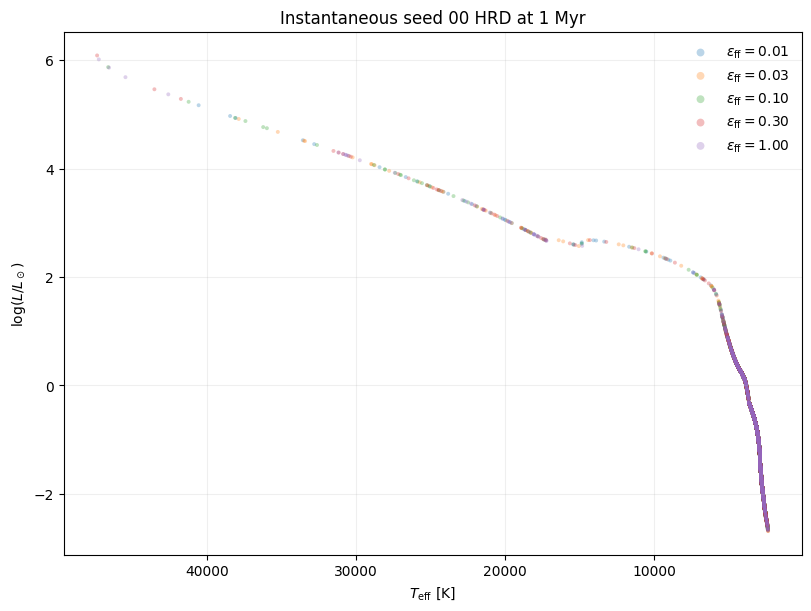

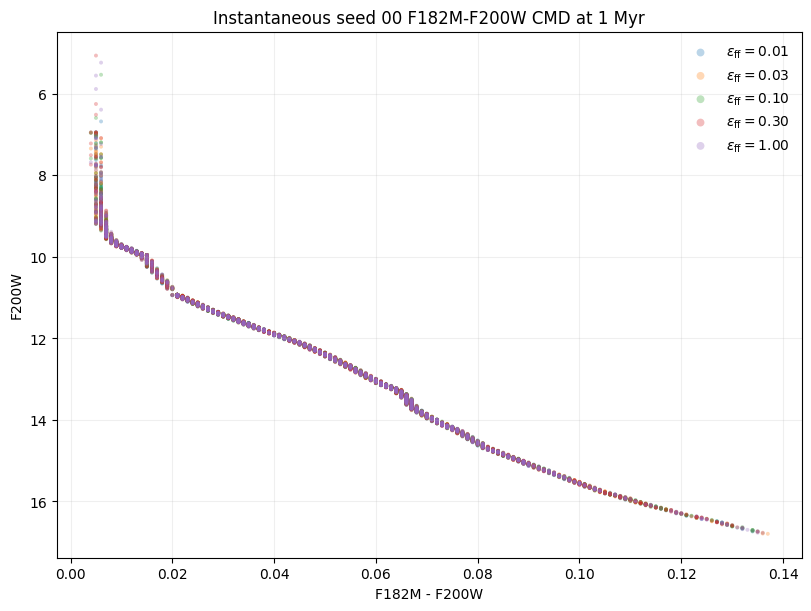

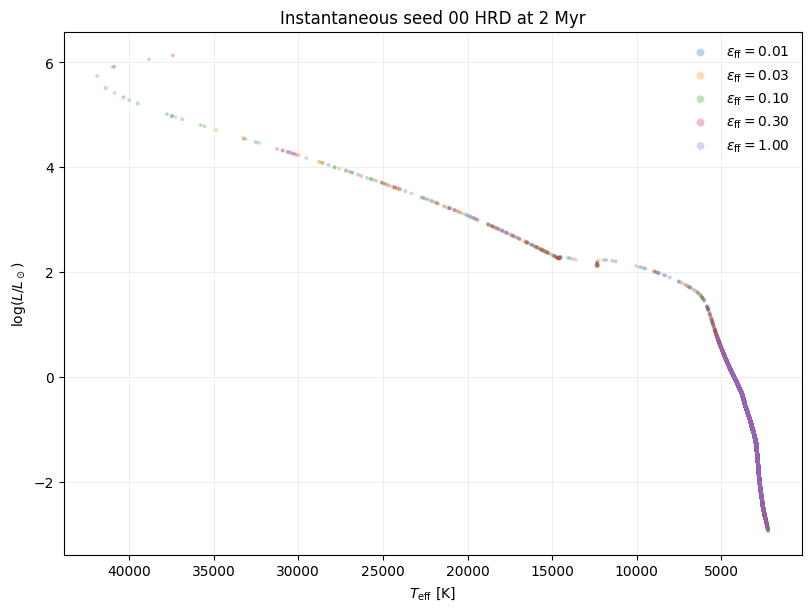

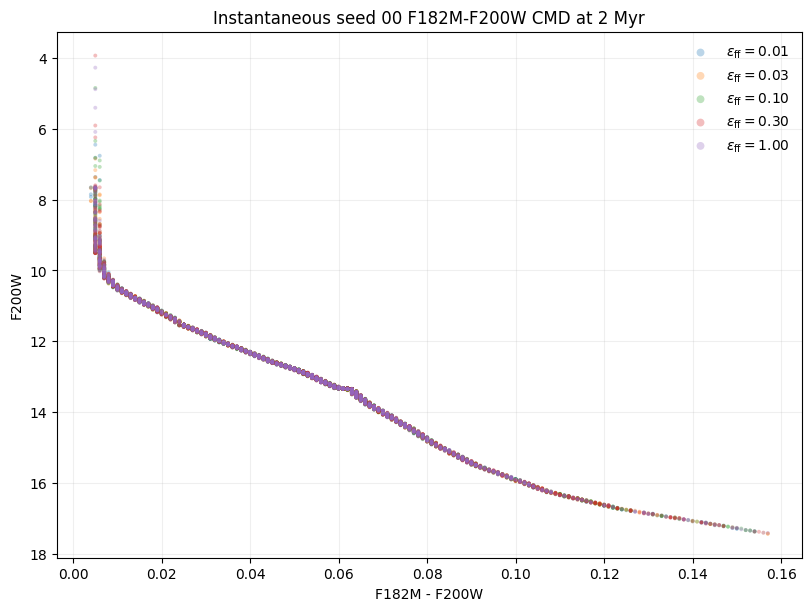

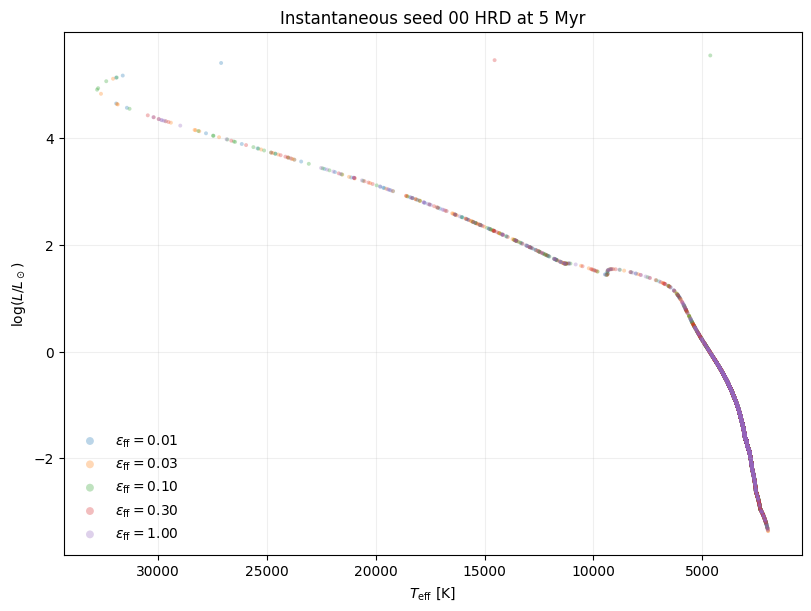

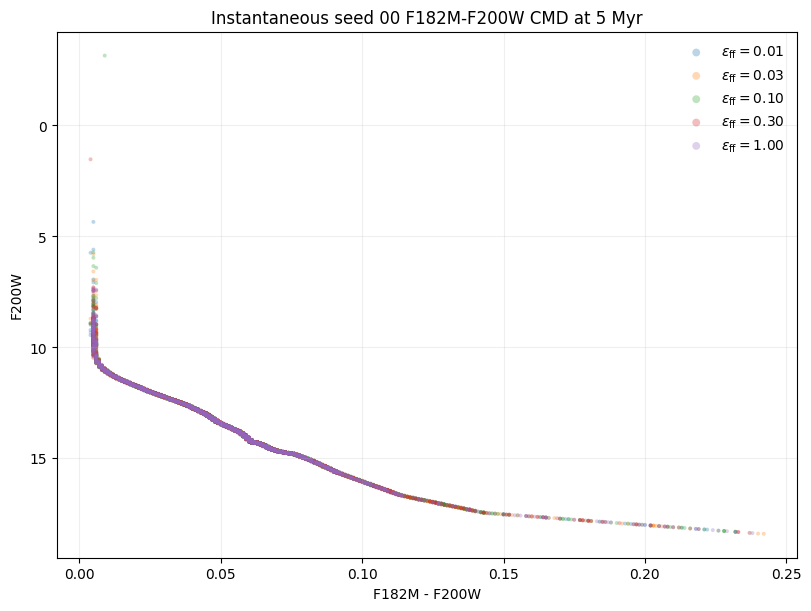

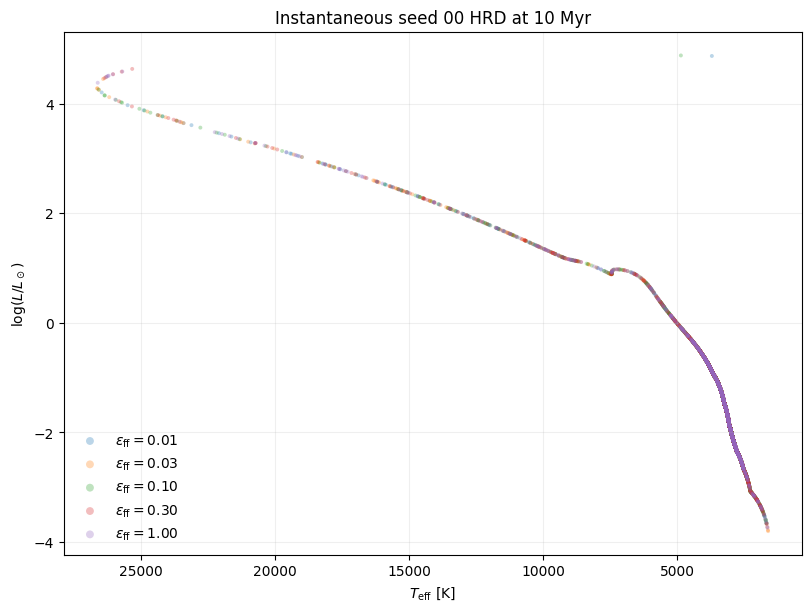

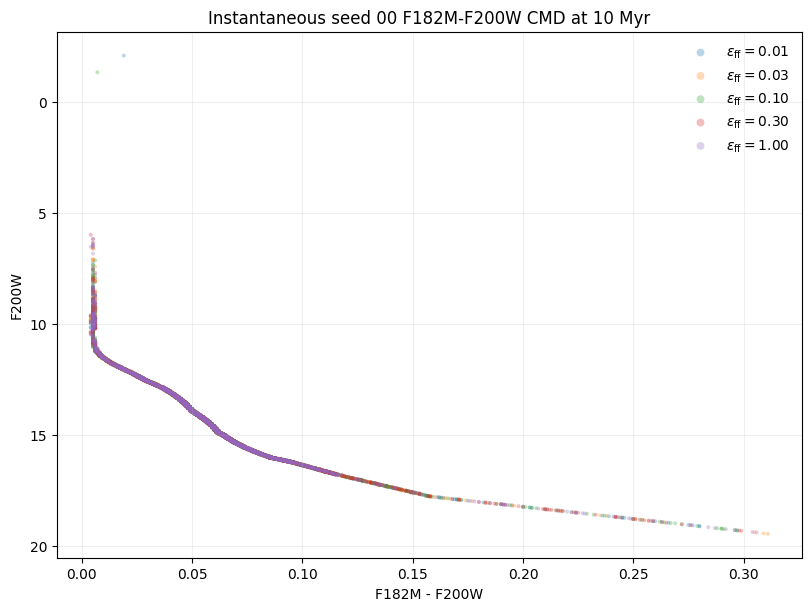

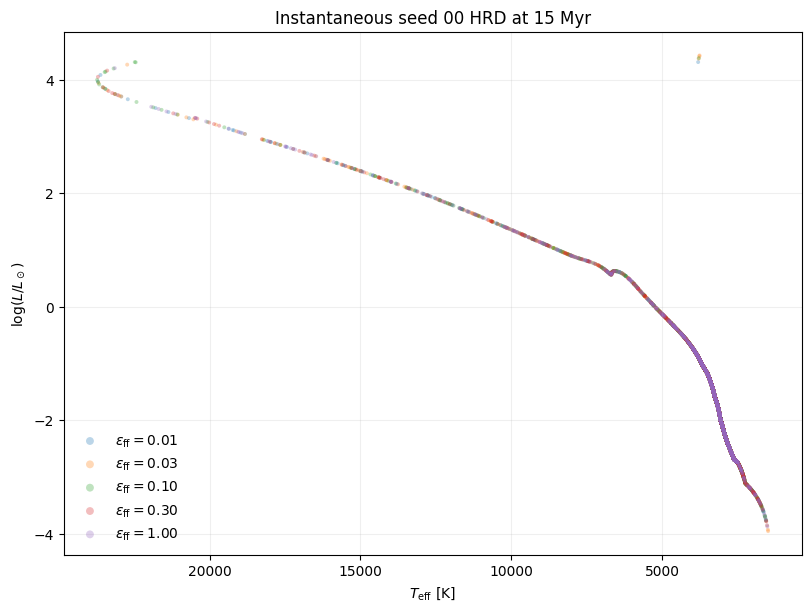

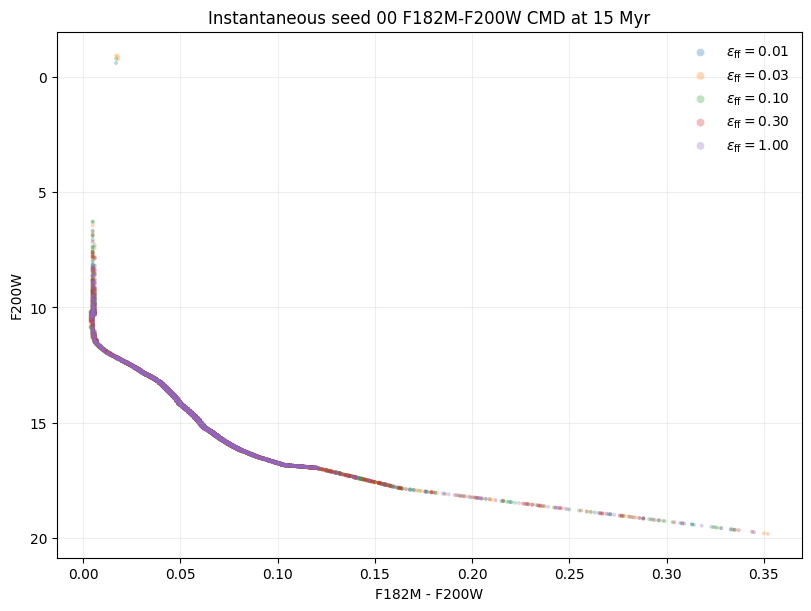

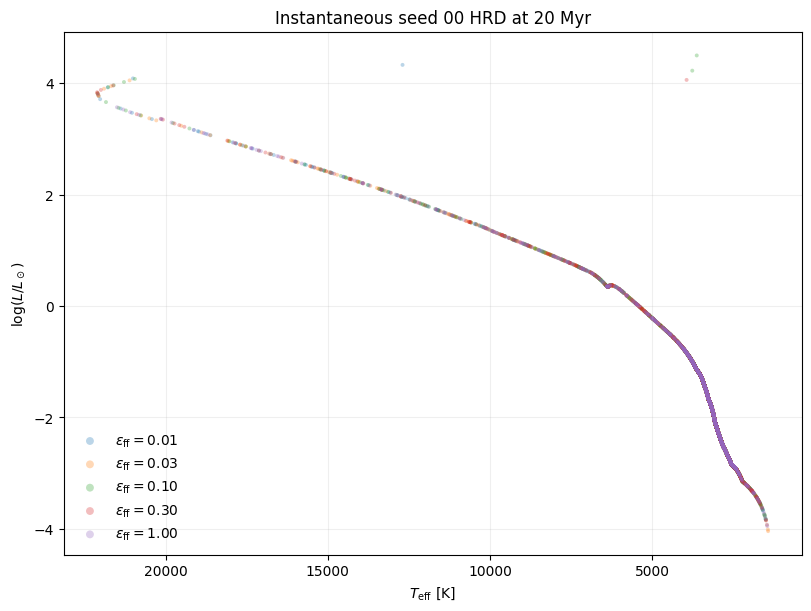

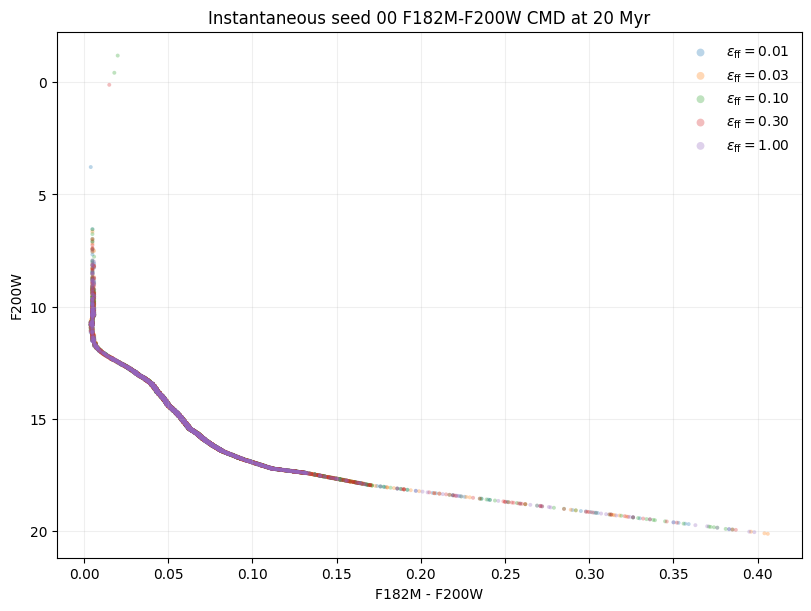

In [14]:
def plot_overlays(time_myr: float):
    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

    for eff in EFF_DIRS:
        df = interpolated[(eff, time_myr)]
        ax.scatter(
            df['teff'],
            df['log_luminosity_lsun'],
            s=8,
            alpha=0.30,
            edgecolors='none',
            label=rf'$\epsilon_{{\rm ff}}={eff:.2f}$',
        )

    ax.invert_xaxis()
    ax.set_xlabel(r'$T_{\rm eff}$ [K]')
    ax.set_ylabel(r'$\log(L/L_\odot)$')
    ax.set_title(f'Instantaneous seed 00 HRD at {time_myr:g} Myr')
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, markerscale=2)
    finish_figure(
        fig,
        f'instantaneous_overlay_hr_t{time_myr:04.1f}myr.png',
    )

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

    for eff in EFF_DIRS:
        df = interpolated[(eff, time_myr)]
        x = df['mag_F182M'] - df['mag_F200W']
        y = df['mag_F200W']

        ax.scatter(
            x,
            y,
            s=8,
            alpha=0.30,
            edgecolors='none',
            label=rf'$\epsilon_{{\rm ff}}={eff:.2f}$',
        )

    ax.invert_yaxis()
    ax.set_xlabel('F182M - F200W')
    ax.set_ylabel('F200W')
    ax.set_title(
        f'Instantaneous seed 00 F182M-F200W CMD at {time_myr:g} Myr'
    )
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, markerscale=2)
    finish_figure(
        fig,
        f'instantaneous_overlay_f182m_f200w_t{time_myr:04.1f}myr.png',
    )


for time_myr in CHECK_TIMES_MYR:
    plot_overlays(float(time_myr))

## Final verdict

In [15]:
final_rows = []

for eff in EFF_DIRS:
    mass_row = df_mass_comparison.loc[
        np.isclose(df_mass_comparison['epsilon_ff'], eff)
    ].iloc[0]

    synth_rows = df_synthetic_summary.loc[
        np.isclose(df_synthetic_summary['epsilon_ff'], eff)
    ]

    dist_row = df_distribution.loc[
        np.isclose(df_distribution['epsilon_ff'], eff)
    ].iloc[0]

    final_rows.append({
        'epsilon_ff': eff,
        'exact_same_component_population': bool(
            mass_row[
                'exact_same_unordered_component_mass_multiset'
            ]
        ),
        'exact_same_primary_system_population': bool(
            mass_row[
                'exact_same_unordered_primary_mass_multiset'
            ]
        ),
        'exact_same_synthetic_population_at_all_tested_ages': bool(
            synth_rows[
                'all_sorted_synthetic_columns_same'
            ].all()
        ),
        'component_count': int(dist_row['n_components']),
        'total_component_mass_msun': float(dist_row['total_mass_msun']),
        'empirical_ks_mass_distance_vs_eff003': float(
            dist_row['empirical_ks_distance_vs_eff003']
        ),
    })


df_final = pd.DataFrame(final_rows)

print('\n' + '=' * 80)
print('FINAL INSTANTANEOUS-CONTROL COMPARISON')
print('=' * 80)
show_table(df_final)

df_final.to_csv(
    OUTPUT_DIR / 'final_instantaneous_control_comparison.csv',
    index=False,
)

print(f'\nOutputs written to: {OUTPUT_DIR.resolve()}')


FINAL INSTANTANEOUS-CONTROL COMPARISON


,epsilon_ff,exact_same_component_population,exact_same_primary_system_population,exact_same_synthetic_population_at_all_tested_ages,component_count,total_component_mass_msun,empirical_ks_mass_distance_vs_eff003
0,0.01,False,False,False,4290,1501.500000,0.015857
1,0.03,True,True,True,4233,1498.482001,0.000000
2,0.10,False,False,False,3796,1499.420000,0.013923
3,0.30,False,False,False,3708,1501.740000,0.015036
4,1.00,False,False,False,3522,1500.371999,0.016976



Outputs written to: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-06_compare-seeds-across-e_ff/iteration3-compare-instantaneous/seed00_instantaneous_across_eff_outputs
